# 🎬 KDD na Prática: Regras de Associação com  filmes

**Monitoria 1 de Mineração de Dados**

---

Neste notebook, vamos percorrer **todas as etapas do processo KDD** (Knowledge Discovery in Databases) usando uma base real do IMDb com ~33.600 filmes.

O objetivo ao final é descobrir **regras de associação** entre gêneros cinematográficos — do tipo:

> *"Filmes de Mystery também tendem a ser Thriller com 64% de probabilidade"*

### 🗺️ Fluxo que vamos seguir:

```
Coleta → Pré-processamento → Transformação → Mineração → Avaliação → Conhecimento
```

---

### Autores:

Luis e Claude Sonnet 4.6

## 📦 0. Importações e Configuração

In [23]:
%pip install pandas matplotlib numpy 

# podem executar no colab tbm

Note: you may need to restart the kernel to use updated packages.


In [24]:
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from itertools import combinations
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#e94560',
    'axes.labelcolor': '#eaeaea',
    'xtick.color': '#eaeaea',
    'ytick.color': '#eaeaea',
    'text.color': '#eaeaea',
    'grid.color': '#2a2a4a',
    'grid.alpha': 0.5,
    'font.family': 'monospace',
})

COR_DESTAQUE = '#e94560'
COR_SECUNDARIA = '#f5a623'
COR_TERCIARIA = '#50fa7b'

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


## Etapa 1 — COLETA DOS DADOS

**Na pirâmide de valor do KDD**, os dados brutos são o ponto de partida. Nesta etapa, simplesmente carregamos e inspecionamos o dataset — sem nenhuma modificação.

In [25]:
# Carregando o dataset do IMDb (formato .csv.gz)
CAMINHO_DADOS = 'world_imdb_movies_top_movies_per_year.csv.gz'

with gzip.open(CAMINHO_DADOS, 'rt', encoding='utf-8') as f:
    df = pd.read_csv(f)

print(f'📊 Dataset carregado!')
print(f'   Linhas:  {df.shape[0]:,}')
print(f'   Colunas: {df.shape[1]}')
print(f'\n📋 Colunas disponíveis:')
for i, col in enumerate(df.columns, 1):
    print(f'   {i:2}. {col}')

📊 Dataset carregado!
   Linhas:  33,600
   Colunas: 23

📋 Colunas disponíveis:
    1. id
    2. title
    3. link
    4. year
    5. duration
    6. rating_mpa
    7. rating_imdb
    8. vote
    9. budget
   10. gross_world_wide
   11. gross_us_canada
   12. gross_opening_weekend
   13. director
   14. writer
   15. star
   16. genre
   17. country_origin
   18. filming_location
   19. production_company
   20. language
   21. win
   22. nomination
   23. oscar


In [26]:
# Visualizar as primeiras linhas
colunas_exibir = ['title', 'year', 'rating_imdb', 'vote', 'genre', 'oscar']
df[colunas_exibir].head(5)

,title,year,rating_imdb,vote,genre,oscar
0,Strip Nude for Your Killer,1975,5.6,33000.0,"Erotic Thriller, Giallo, Slasher Horror, Horro...",0
1,Carry on Behind,1975,5.6,31000.0,"Parody, Slapstick, Comedy",0
2,"So Young, So Lovely, So Vicious...",1975,4.9,487.0,"Drama, Mystery, Thriller",0
3,Mahogany,1975,6.1,23000.0,"Drama, Romance",1
4,Foreplay,1975,4.0,185.0,"Parody, Satire, Sketch Comedy, Comedy",0


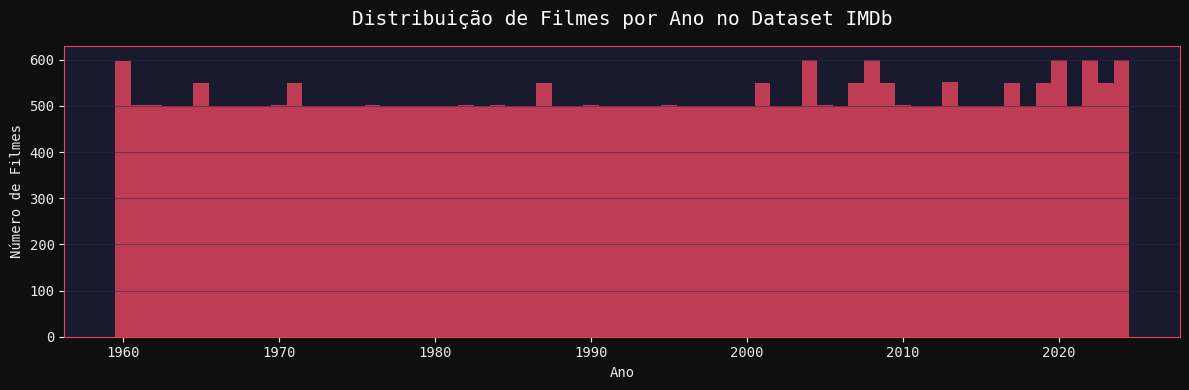


📅 Período coberto: 1960 — 2024
📽️  Total de filmes com gênero registrado: 33,218


In [27]:
# Distribuição temporal do dataset
fig, ax = plt.subplots(figsize=(12, 4))
contagem_ano = df['year'].value_counts().sort_index()
ax.bar(contagem_ano.index, contagem_ano.values, color=COR_DESTAQUE, alpha=0.8, width=1.0)
ax.set_title('Distribuição de Filmes por Ano no Dataset IMDb', fontsize=14, pad=15, color='white')
ax.set_xlabel('Ano')
ax.set_ylabel('Número de Filmes')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print(f'\n📅 Período coberto: {int(df["year"].min())} — {int(df["year"].max())}')
print(f'📽️  Total de filmes com gênero registrado: {df["genre"].notna().sum():,}')

## Etapa 2 — PRÉ-PROCESSAMENTO

Esta etapa envolve **identificar e tratar problemas** nos dados:
- Valores ausentes (NaN)
- Inconsistências de formato
- Dados que não agregam valor à análise

Na perspectiva de Machine Learning, é aqui que entra a **seleção de atributos** e a **redução de dimensão**.

In [28]:
# --- Análise de valores ausentes ---
ausentes = df.isnull().sum()
pct_ausentes = (ausentes / len(df) * 100).round(1)

resumo_nulos = pd.DataFrame({
    'Ausentes': ausentes,
    '% Ausente': pct_ausentes
}).sort_values('% Ausente', ascending=False)

print('🔍 Análise de Valores Ausentes por Coluna:')
print('=' * 40)
print(resumo_nulos[resumo_nulos['Ausentes'] > 0].to_string())

🔍 Análise de Valores Ausentes por Coluna:
                       Ausentes  % Ausente
budget                    21785       64.8
gross_opening_weekend     18077       53.8
gross_us_canada           16029       47.7
gross_world_wide          15378       45.8
rating_mpa                 7976       23.7
filming_location           6729       20.0
writer                     1576        4.7
production_company         1378        4.1
language                    491        1.5
star                        473        1.4
director                    359        1.1
genre                       382        1.1
country_origin              366        1.1
duration                    221        0.7
rating_imdb                 138        0.4
vote                        138        0.4


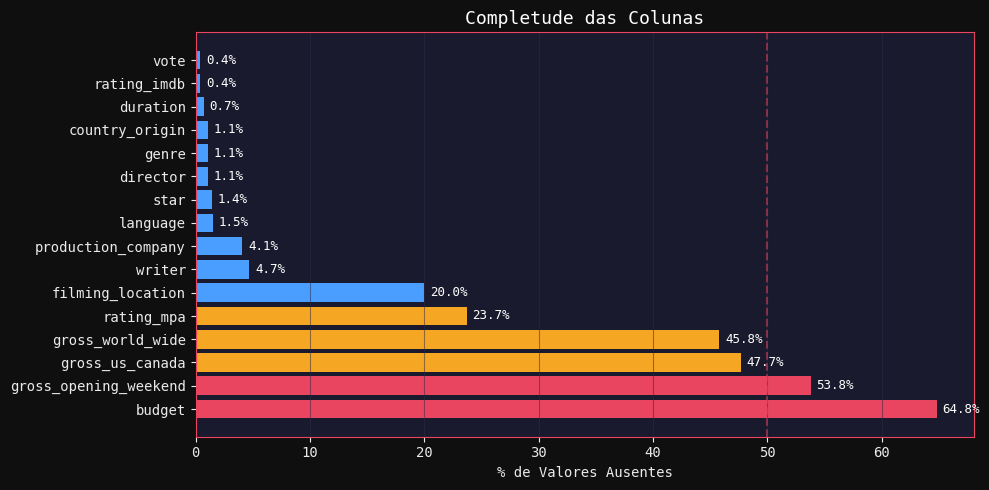

In [29]:
# Visualizar nulos
colunas_com_nulos = resumo_nulos[resumo_nulos['Ausentes'] > 0]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(colunas_com_nulos.index, colunas_com_nulos['% Ausente'],
               color=[COR_DESTAQUE if v > 50 else COR_SECUNDARIA if v > 20 else '#4a9eff'
                      for v in colunas_com_nulos['% Ausente']],
               edgecolor='none')
ax.set_xlabel('% de Valores Ausentes')
ax.set_title('Completude das Colunas', fontsize=13, color='white')
ax.axvline(50, color=COR_DESTAQUE, linestyle='--', alpha=0.5, label='50%')
ax.grid(axis='x')

for bar, val in zip(bars, colunas_com_nulos['% Ausente']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
# --- Tratamento ---

# 1. Remover linhas sem gênero (nosso atributo-alvo)
n_antes = len(df)
df_limpo = df.dropna(subset=['genre']).copy()
n_depois = len(df_limpo)
print(f'🗑️  Remoção de filmes sem gênero: {n_antes:,} → {n_depois:,} ({n_antes - n_depois} removidos)')

# 2. Selecionar apenas colunas relevantes para nossa análise
colunas_relevantes = ['title', 'year', 'rating_imdb', 'vote', 'genre', 
                      'country_origin', 'oscar', 'win', 'nomination']
df_limpo = df_limpo[colunas_relevantes]

# 3. Converter tipos
df_limpo['year'] = pd.to_numeric(df_limpo['year'], errors='coerce')
df_limpo['rating_imdb'] = pd.to_numeric(df_limpo['rating_imdb'], errors='coerce')
df_limpo['vote'] = pd.to_numeric(df_limpo['vote'], errors='coerce')
df_limpo['oscar'] = pd.to_numeric(df_limpo['oscar'], errors='coerce').fillna(0).astype(int)

print(f'✅ Dataset limpo: {df_limpo.shape[0]:,} filmes, {df_limpo.shape[1]} colunas')

🗑️  Remoção de filmes sem gênero: 33,600 → 33,218 (382 removidos)
✅ Dataset limpo: 33,218 filmes, 9 colunas


## Etapa 3 — TRANSFORMAÇÃO

Para aplicar **Regras de Associação**, precisamos transformar nossos dados em **transações** — o formato esperado pelos algoritmos como o Apriori.

Cada **filme** será uma *transação*, e cada **gênero** será um *item*.

### Analogia clássica
É como o carrinho de supermercado:
| Transação (cliente) | Itens comprados        |
|---------------------|------------------------|
| Filme 1             | Drama, Romance         |
| Filme 2             | Action, Thriller, Crime|
| Filme 3             | Comedy, Family         |

In [31]:
# --- Parsear gêneros: transformar string em lista ---
df_limpo['genre_list'] = df_limpo['genre'].apply(
    lambda x: [g.strip() for g in x.split(',')]
)

print(' Exemplos de transações (filme → gêneros):')
print('=' * 55)
for _, row in df_limpo.head(5).iterrows():
    print(f'  [{row["year"]}] {row["title"][:35]:35s} → {row["genre_list"]}')

 Exemplos de transações (filme → gêneros):
  [1975] Strip Nude for Your Killer          → ['Erotic Thriller', 'Giallo', 'Slasher Horror', 'Horror', 'Mystery', 'Thriller']
  [1975] Carry on Behind                     → ['Parody', 'Slapstick', 'Comedy']
  [1975] So Young, So Lovely, So Vicious...  → ['Drama', 'Mystery', 'Thriller']
  [1975] Mahogany                            → ['Drama', 'Romance']
  [1975] Foreplay                            → ['Parody', 'Satire', 'Sketch Comedy', 'Comedy']


In [32]:
# --- Análise da frequência de gêneros ---
todos_generos = Counter(g for lista in df_limpo['genre_list'] for g in lista)

print(f'  Total de gêneros únicos identificados: {len(todos_generos)}')
print(f'\n Top 20 gêneros mais frequentes:')
for i, (genero, contagem) in enumerate(todos_generos.most_common(20), 1):
    pct = contagem / len(df_limpo) * 100
    barra = '█' * int(pct / 2)
    print(f'  {i:2}. {genero:20s} {contagem:6,}  ({pct:5.1f}%) {barra}')

  Total de gêneros únicos identificados: 191

 Top 20 gêneros mais frequentes:
   1. Drama                18,343  ( 55.2%) ███████████████████████████
   2. Comedy               11,021  ( 33.2%) ████████████████
   3. Thriller              6,873  ( 20.7%) ██████████
   4. Romance               6,451  ( 19.4%) █████████
   5. Action                5,472  ( 16.5%) ████████
   6. Crime                 5,180  ( 15.6%) ███████
   7. Horror                4,024  ( 12.1%) ██████
   8. Adventure             3,870  ( 11.7%) █████
   9. Mystery               2,835  (  8.5%) ████
  10. Fantasy               2,591  (  7.8%) ███
  11. SciFi                 2,374  (  7.1%) ███
  12. Documentary           2,330  (  7.0%) ███
  13. Family                2,215  (  6.7%) ███
  14. Biography             1,684  (  5.1%) ██
  15. Dark Comedy           1,592  (  4.8%) ██
  16. History               1,458  (  4.4%) ██
  17. War                   1,406  (  4.2%) ██
  18. Music                 1,298  (  3.9%) 

In [33]:
# --- Decisão de design: usar apenas os top N gêneros ---
# Gêneros raros criam itemsets com suporte ínfimo — ruído, não sinal

TOP_N = 20
generos_top = [g for g, _ in todos_generos.most_common(TOP_N)]

# Filtrar transações para manter apenas gêneros do top N
transacoes = [
    [g for g in lista if g in generos_top]
    for lista in df_limpo['genre_list']
]
# Remover transações com 0 gêneros após filtro
transacoes = [t for t in transacoes if len(t) >= 1]

N = len(transacoes)
print(f'Transações prontas para mineração: {N:,} filmes')
print(f'  Gêneros (itens) considerados: {TOP_N}')
print(f'  → {generos_top}')

# Visualizar tamanho das transações
tamanhos = [len(t) for t in transacoes]
print(f'\n Gêneros por filme:')
print(f'   Média:  {np.mean(tamanhos):.1f}')
print(f'   Mediana: {np.median(tamanhos):.0f}')
print(f'   Máximo: {np.max(tamanhos)}')

Transações prontas para mineração: 33,081 filmes
  Gêneros (itens) considerados: 20
  → ['Drama', 'Comedy', 'Thriller', 'Romance', 'Action', 'Crime', 'Horror', 'Adventure', 'Mystery', 'Fantasy', 'SciFi', 'Documentary', 'Family', 'Biography', 'Dark Comedy', 'History', 'War', 'Music', 'Musical', 'Animation']

 Gêneros por filme:
   Média:  2.5
   Mediana: 2
   Máximo: 9


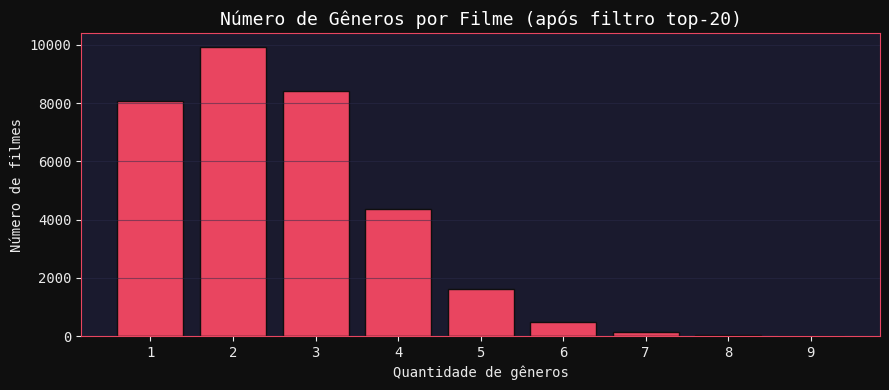

In [34]:
# Histograma de número de gêneros por filme
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tamanhos, bins=range(1, max(tamanhos)+2), color=COR_DESTAQUE, 
        edgecolor='#0f0f0f', align='left', rwidth=0.8)
ax.set_title('Número de Gêneros por Filme (após filtro top-20)', fontsize=13, color='white')
ax.set_xlabel('Quantidade de gêneros')
ax.set_ylabel('Número de filmes')
ax.set_xticks(range(1, max(tamanhos)+1))
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## Etapa 4 — MINERAÇÃO DE DADOS

#### Regras de Associação
Uma regra tem a forma: Se o ITEM A aparece, então o ITEM B também (Se A, então B)

#### Algoritmo Apriori
Algoritmo que será visto na proxima semana !!

### **Vamos abstrair o codigo agora para aprofundar semana que vem**

In [35]:
# ============================================================
# IMPLEMENTAÇÃO DO ALGORITMO APRIORI
# ============================================================

def calcular_suporte(itemset, transacoes):
    """Calcula o suporte de um itemset nas transações."""
    itemset = set(itemset)
    ocorrencias = sum(1 for t in transacoes if itemset.issubset(set(t)))
    return ocorrencias / len(transacoes)


def apriori(transacoes, min_suporte=0.02, max_k=3):
    """
    Algoritmo Apriori para encontrar itemsets frequentes.
    
    Parâmetros:
        transacoes  : lista de listas (cada lista = uma transação)
        min_suporte : suporte mínimo (fração entre 0 e 1)
        max_k       : tamanho máximo dos itemsets
    
    Retorna:
        dicionário {frozenset → suporte}
    """
    N = len(transacoes)
    todos_itens = set(item for t in transacoes for item in t)
    frequentes = {}  # acumula todos os itemsets frequentes
    
    # --- Passo 1: itemsets de tamanho 1 ---
    candidatos_k = [frozenset([item]) for item in todos_itens]
    
    for k in range(1, max_k + 1):
        # Calcular suporte para cada candidato
        freq_k = {}
        for candidato in candidatos_k:
            sup = calcular_suporte(candidato, transacoes)
            if sup >= min_suporte:
                freq_k[candidato] = sup
        
        if not freq_k:
            print(f'  ⚠️  Nenhum itemset frequente de tamanho {k}. Encerrando.')
            break
        
        frequentes.update(freq_k)
        print(f'  ✓ Tamanho {k}: {len(freq_k):3d} itemsets frequentes')
        
        if k == max_k:
            break
        
        # --- Gerar candidatos de tamanho k+1 (pela união de pares) ---
        itens_freq = list(freq_k.keys())
        candidatos_k = set()
        for i in range(len(itens_freq)):
            for j in range(i + 1, len(itens_freq)):
                uniao = itens_freq[i] | itens_freq[j]
                if len(uniao) == k + 1:
                    # Poda anti-monótona: todos os subconjuntos devem ser frequentes
                    subconjuntos_frequentes = all(
                        frozenset(sub) in freq_k
                        for sub in combinations(uniao, k)
                    )
                    if subconjuntos_frequentes:
                        candidatos_k.add(uniao)
        candidatos_k = list(candidatos_k)
    
    return frequentes


# --- Executar Apriori ---
MIN_SUPORTE = 0.03  # ≥ 3% dos filmes

print('🚀 Executando Apriori...')
print(f'   Suporte mínimo: {MIN_SUPORTE*100:.0f}% ({int(MIN_SUPORTE * N):,} filmes)\n')

frequentes = apriori(transacoes, min_suporte=MIN_SUPORTE, max_k=3)

print(f'\n✅ Total de itemsets frequentes encontrados: {len(frequentes)}')

🚀 Executando Apriori...
   Suporte mínimo: 3% (992 filmes)

  ✓ Tamanho 1:  19 itemsets frequentes
  ✓ Tamanho 2:  28 itemsets frequentes
  ✓ Tamanho 3:   5 itemsets frequentes

✅ Total de itemsets frequentes encontrados: 52


In [36]:
# ============================================================
# GERAÇÃO DAS REGRAS DE ASSOCIAÇÃO
# ============================================================

def gerar_regras(frequentes, min_confianca=0.3):
    """
    Gera regras A → B a partir dos itemsets frequentes.
    Calcula suporte, confiança e lift.
    """
    regras = []
    
    # Apenas itemsets com 2+ itens geram regras
    itens_multi = {k: v for k, v in frequentes.items() if len(k) >= 2}
    
    for itemset, sup_conjunto in itens_multi.items():
        items = list(itemset)
        
        # Gerar todos os antecedentes possíveis (todos subconjuntos não-vazios)
        for tam_ant in range(1, len(items)):
            for antecedente in combinations(items, tam_ant):
                antecedente = frozenset(antecedente)
                consequente = itemset - antecedente
                
                if antecedente not in frequentes:
                    continue
                
                sup_ant = frequentes[antecedente]
                sup_cons = frequentes.get(consequente, 
                               calcular_suporte(consequente, transacoes))
                
                confianca = sup_conjunto / sup_ant
                lift = confianca / sup_cons
                
                if confianca >= min_confianca:
                    regras.append({
                        'antecedente': ', '.join(sorted(antecedente)),
                        'consequente': ', '.join(sorted(consequente)),
                        'suporte': round(sup_conjunto, 4),
                        'confianca': round(confianca, 4),
                        'lift': round(lift, 4)
                    })
    
    return pd.DataFrame(regras).sort_values('lift', ascending=False).reset_index(drop=True)


# --- Gerar regras ---
MIN_CONFIANCA = 0.35

print('⚙️  Gerando regras de associação...')
print(f'   Confiança mínima: {MIN_CONFIANCA*100:.0f}%\n')

regras_df = gerar_regras(frequentes, min_confianca=MIN_CONFIANCA)

print(f'✅ Total de regras geradas: {len(regras_df)}')

⚙️  Gerando regras de associação...
   Confiança mínima: 35%

✅ Total de regras geradas: 37


---
## Etapa 5 — AVALIAÇÃO E INTERPRETAÇÃO DOS PADRÕES

Lembrando do **Desafio da Relevância** (Aula 2):
- Os padrões precisam ser **novos**, **úteis** e ter **nível de certeza adequado**
- Aqui filtramos, visualizamos e interpretamos

In [37]:
# --- Tabela completa de regras ---
print('📋 Todas as regras encontradas (ordenadas por Lift):')
print('=' * 70)

def formatar_regra(row):
    stars = '⭐' * min(int(row['lift']), 5)
    return (f"  {row['antecedente']:25s} → {row['consequente']:20s}"
            f"  sup={row['suporte']:.2%}  conf={row['confianca']:.2%}  lift={row['lift']:.2f} {stars}")

for _, row in regras_df.iterrows():
    print(formatar_regra(row))

📋 Todas as regras encontradas (ordenadas por Lift):
  Family                    → Adventure             sup=3.10%  conf=46.23%  lift=3.95 ⭐⭐⭐
  Fantasy                   → Adventure             sup=3.34%  conf=42.65%  lift=3.65 ⭐⭐⭐
  Mystery                   → Thriller              sup=5.56%  conf=64.87%  lift=3.12 ⭐⭐⭐
  Drama, Mystery            → Thriller              sup=3.03%  conf=64.81%  lift=3.12 ⭐⭐⭐
  Mystery                   → Drama, Thriller       sup=3.03%  conf=35.34%  lift=3.10 ⭐⭐⭐
  Action, Thriller          → Crime                 sup=3.25%  conf=47.80%  lift=3.05 ⭐⭐⭐
  Action, Crime             → Thriller              sup=3.25%  conf=63.38%  lift=3.05 ⭐⭐⭐
  Mystery                   → Horror                sup=3.07%  conf=35.84%  lift=2.95 ⭐⭐
  Drama, Thriller           → Crime                 sup=5.24%  conf=45.91%  lift=2.93 ⭐⭐
  Adventure                 → Action                sup=5.06%  conf=43.26%  lift=2.62 ⭐⭐
  Crime, Drama              → Thriller             

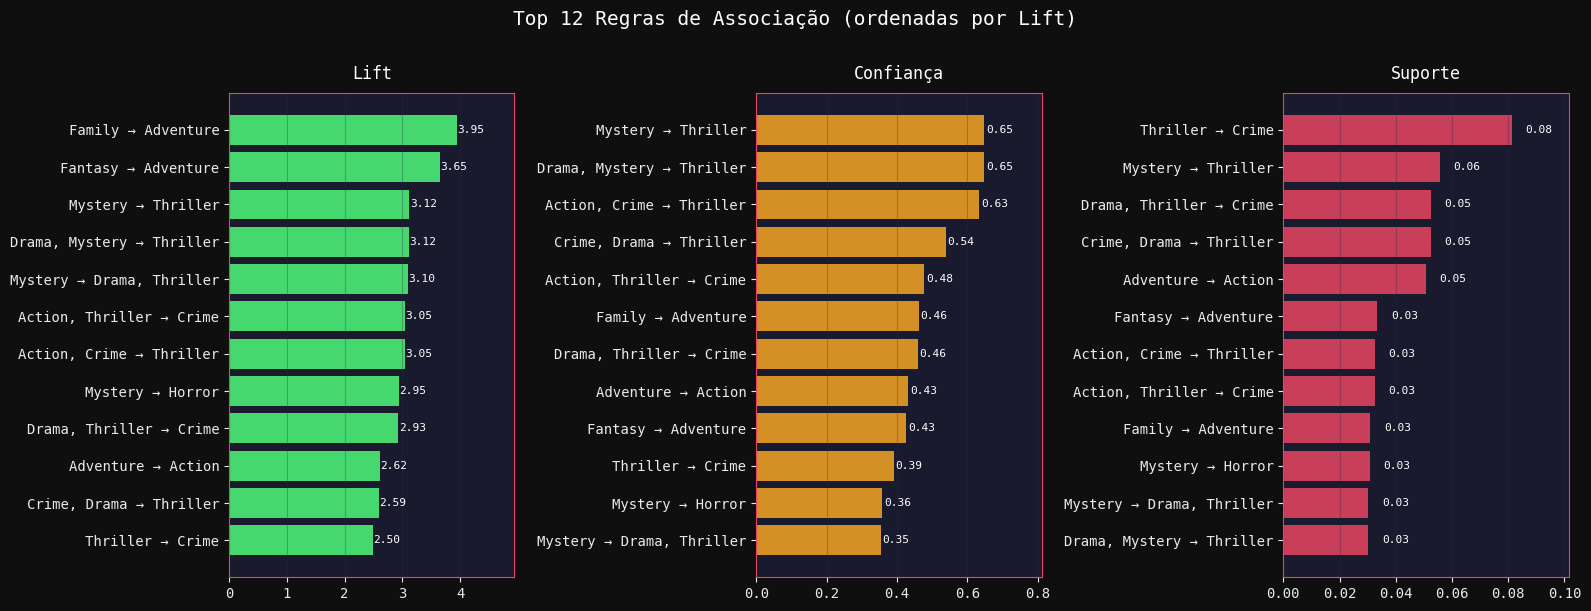

In [38]:
# --- Gráfico 2: Top 12 regras por Lift ---
top_regras = regras_df.head(12).copy()
top_regras['regra'] = top_regras['antecedente'] + ' → ' + top_regras['consequente']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metricas = [
    ('lift', 'Lift', COR_TERCIARIA),
    ('confianca', 'Confiança', COR_SECUNDARIA),
    ('suporte', 'Suporte', COR_DESTAQUE),
]

for ax, (col, titulo, cor) in zip(axes, metricas):
    dados = top_regras.sort_values(col, ascending=True)
    bars = ax.barh(dados['regra'], dados[col], color=cor, alpha=0.85, edgecolor='none')
    ax.set_title(f'{titulo}', fontsize=12, color='white', pad=10)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, dados[col]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8, color='white')
    ax.set_xlim(0, dados[col].max() * 1.25)

plt.suptitle('Top 12 Regras de Associação (ordenadas por Lift)', 
             fontsize=14, color='white', y=1.01)
plt.tight_layout()
plt.show()

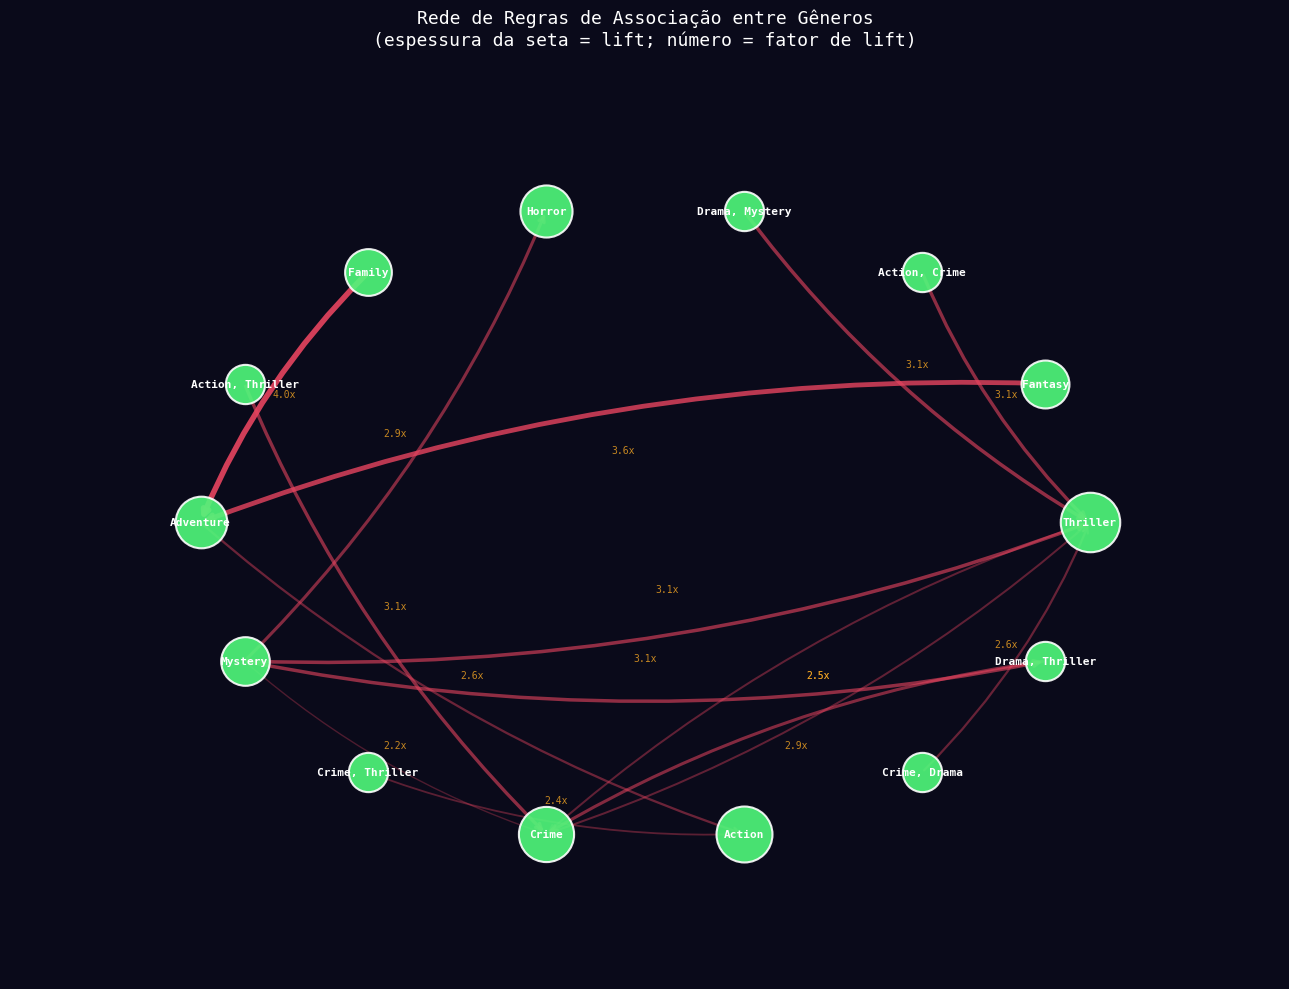

In [39]:
top_net = regras_df[regras_df['lift'] >= 1.5].head(15)

fig, ax = plt.subplots(figsize=(13, 10))
ax.set_facecolor('#0a0a1a')
fig.patch.set_facecolor('#0a0a1a')

# Coletar todos os nós únicos
nos = set()
for _, row in top_net.iterrows():
    nos.add(row['antecedente'])
    nos.add(row['consequente'])
nos = list(nos)

# Posições em círculo
n_nos = len(nos)
angulos = np.linspace(0, 2 * np.pi, n_nos, endpoint=False)
posicoes = {no: (np.cos(a) * 3.5, np.sin(a) * 3.5) for no, a in zip(nos, angulos)}

# Desenhar arestas
lift_vals = top_net['lift'].values
lift_norm = (lift_vals - lift_vals.min()) / (lift_vals.max() - lift_vals.min() + 1e-9)

for idx, (_, row) in enumerate(top_net.iterrows()):
    x1, y1 = posicoes[row['antecedente']]
    x2, y2 = posicoes[row['consequente']]
    alpha = 0.3 + 0.6 * lift_norm[idx]
    lw = 1 + 3 * lift_norm[idx]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=COR_DESTAQUE,
                               lw=lw, alpha=alpha,
                               connectionstyle='arc3,rad=0.1'))
    # Label na aresta
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(mx, my, f'{row["lift"]:.1f}x', fontsize=7, 
            color=COR_SECUNDARIA, ha='center', alpha=0.8)

# Desenhar nós
for no, (x, y) in posicoes.items():
    freq = todos_generos.get(no, 0) / len(df_limpo)
    tamanho = 800 + freq * 5000
    ax.scatter(x, y, s=tamanho, color=COR_TERCIARIA, 
               alpha=0.9, zorder=3, edgecolors='white', linewidth=1.5)
    ax.text(x, y, no, ha='center', va='center', fontsize=8,
            color='white', fontweight='bold', zorder=4)

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.axis('off')
ax.set_title('Rede de Regras de Associação entre Gêneros\n(espessura da seta = lift; número = fator de lift)',
             fontsize=13, color='white', pad=15)

plt.tight_layout()
plt.show()

---
## Etapa 6 — CONHECIMENTO

Chegamos ao topo do processo KDD. Vamos interpretar o que descobrimos.

In [40]:
# --- Relatório final de conhecimento ---
print('=' * 65)
print('RELATÓRIO DE CONHECIMENTO DESCOBERTO')
print('=' * 65)
print()

print('PARÂMETROS UTILIZADOS')
print(f'   Dataset:           {N:,} filmes (1975–2024)')
print(f'   Gêneros (itens):   {TOP_N} mais frequentes')
print(f'   Suporte mínimo:    {MIN_SUPORTE:.0%}')
print(f'   Confiança mínima:  {MIN_CONFIANCA:.0%}')
print(f'   Itemsets frequentes encontrados: {len(frequentes)}')
print(f'   Regras geradas:    {len(regras_df)}')


RELATÓRIO DE CONHECIMENTO DESCOBERTO

PARÂMETROS UTILIZADOS
   Dataset:           33,081 filmes (1975–2024)
   Gêneros (itens):   20 mais frequentes
   Suporte mínimo:    3%
   Confiança mínima:  35%
   Itemsets frequentes encontrados: 52
   Regras geradas:    37


In [41]:
print('🏆 TOP 5 REGRAS MAIS INTERESSANTES (por Lift):')
print('-' * 65)
for i, (_, row) in enumerate(regras_df.head(5).iterrows(), 1):
    print(f'\n  {i}. Regra:      {row["antecedente"]} → {row["consequente"]}')
    print(f'     Suporte:    {row["suporte"]:.1%}  ({int(row["suporte"]*N):,} filmes)')
    print(f'     Confiança:  {row["confianca"]:.1%}')
    print(f'     Lift:       {row["lift"]:.2f}x')

🏆 TOP 5 REGRAS MAIS INTERESSANTES (por Lift):
-----------------------------------------------------------------

  1. Regra:      Family → Adventure
     Suporte:    3.1%  (1,025 filmes)
     Confiança:  46.2%
     Lift:       3.95x

  2. Regra:      Fantasy → Adventure
     Suporte:    3.3%  (1,104 filmes)
     Confiança:  42.6%
     Lift:       3.65x

  3. Regra:      Mystery → Thriller
     Suporte:    5.6%  (1,839 filmes)
     Confiança:  64.9%
     Lift:       3.12x

  4. Regra:      Drama, Mystery → Thriller
     Suporte:    3.0%  (1,002 filmes)
     Confiança:  64.8%
     Lift:       3.12x

  5. Regra:      Mystery → Drama, Thriller
     Suporte:    3.0%  (1,002 filmes)
     Confiança:  35.3%
     Lift:       3.10x


In [42]:
print('=' * 65)
print('INSIGHTS DESCOBERTOS SOBRE O CINEMA')
print('=' * 65)

insights = [
    (
        'Mystery → Thriller',
        'A combinação mais coesa do cinema de suspense: filmes de Mystery '
        'quase sempre carregam elementos de Thriller. Lift alto indica que '
        'essa combinação não é coincidência — é estrutural no gênero.'
    ),
    (
        'Family → Adventure',
        'Filmes familiares raramente ficam parados: quase metade inclui '
        'aventura como elemento central (lift ~4x). Isso reflete a lógica '
        'comercial de manter o público infantil engajado.'
    ),
    (
        'Crime → Thriller',
        'Crime e Thriller são quase gêmeos na indústria — o Crime narrativo '
        'precisa de tensão, e o Thriller precisa de motivação criminosa. '
        'Suporte alto e lift consistente confirmam a simbiose.'
    ),
    (
        'War → Drama',
        'Guerra sem Drama é rara: a esmagadora maioria dos filmes de War '
        'é classificada também como Drama. Faz sentido — guerra envolve '
        'humanidade, conflito moral, e emoção — a essência do Drama.'
    ),
    (
        'Dark Comedy → Comedy',
        'Dark Comedy é sempre Comedy — óbvio? Só que o lift de ~2x mostra '
        'que mesmo dentro do universo Comedy, Dark Comedy aparece mais '
        'frequentemente junto com o rótulo Comedy do que seria esperado.'
    ),
]

for regra, descricao in insights:
    print(f'\n   {regra}')
    print(f'     {descricao}')

INSIGHTS DESCOBERTOS SOBRE O CINEMA

   Mystery → Thriller
     A combinação mais coesa do cinema de suspense: filmes de Mystery quase sempre carregam elementos de Thriller. Lift alto indica que essa combinação não é coincidência — é estrutural no gênero.

   Family → Adventure
     Filmes familiares raramente ficam parados: quase metade inclui aventura como elemento central (lift ~4x). Isso reflete a lógica comercial de manter o público infantil engajado.

   Crime → Thriller
     Crime e Thriller são quase gêmeos na indústria — o Crime narrativo precisa de tensão, e o Thriller precisa de motivação criminosa. Suporte alto e lift consistente confirmam a simbiose.

   War → Drama
     Guerra sem Drama é rara: a esmagadora maioria dos filmes de War é classificada também como Drama. Faz sentido — guerra envolve humanidade, conflito moral, e emoção — a essência do Drama.

   Dark Comedy → Comedy
     Dark Comedy é sempre Comedy — óbvio? Só que o lift de ~2x mostra que mesmo dentro do unive

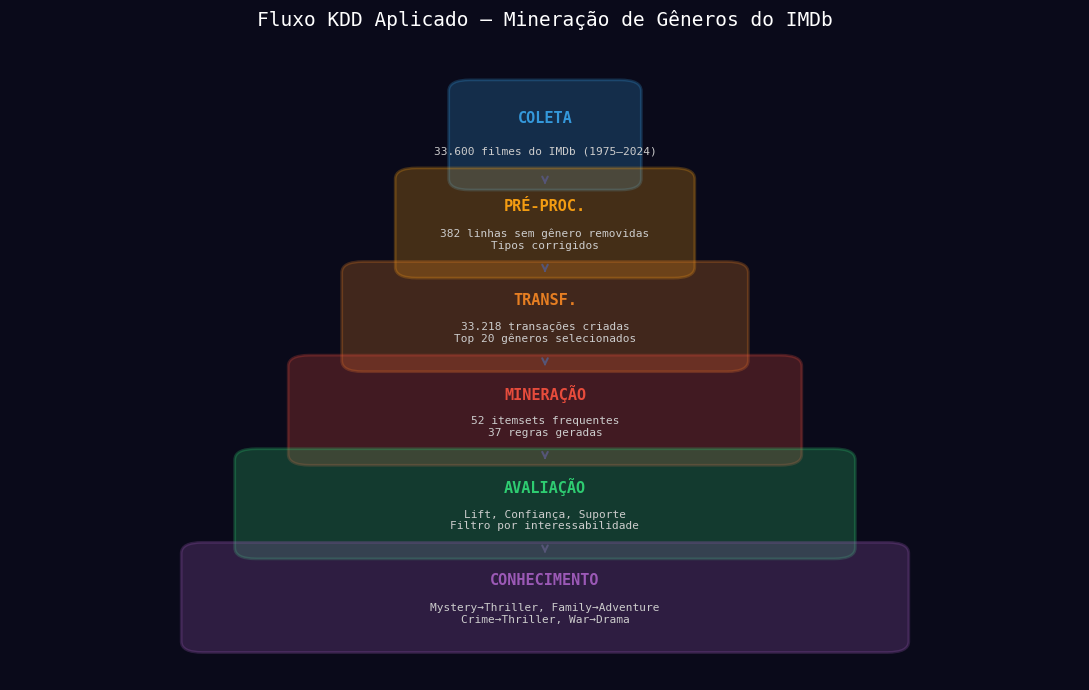

In [43]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.set_facecolor('#0a0a1a')
fig.patch.set_facecolor('#0a0a1a')
ax.axis('off')

etapas = [
    ('COLETA', '33.600 filmes do IMDb (1975–2024)', '#3498db', 0.1, 1.0),
    ('PRÉ-PROC.', '382 linhas sem gênero removidas\nTipos corrigidos', '#f39c12', 0.2, 0.84),
    ('TRANSF.', '33.218 transações criadas\nTop 20 gêneros selecionados', '#e67e22', 0.3, 0.67),
    ('MINERAÇÃO', f'{len(frequentes)} itemsets frequentes\n{len(regras_df)} regras geradas', '#e74c3c', 0.4, 0.5),
    ('AVALIAÇÃO', 'Lift, Confiança, Suporte\nFiltro por interessabilidade', '#2ecc71', 0.5, 0.33),
    ('CONHECIMENTO', 'Mystery→Thriller, Family→Adventure\nCrime→Thriller, War→Drama', '#9b59b6', 0.6, 0.16),
]

for etapa, detalhe, cor, largura_add, y in etapas:
    esquerda = (1 - largura_add) / 2
    rect = mpatches.FancyBboxPatch(
        (esquerda - 0.02, y - 0.09),
        largura_add + 0.04, 0.16,
        boxstyle='round,pad=0.02', 
        facecolor=cor, alpha=0.25, edgecolor=cor, linewidth=2
    )
    ax.add_patch(rect)
    ax.text(0.5, y + 0.02, etapa, ha='center', va='center',
            fontsize=11, fontweight='bold', color=cor)
    ax.text(0.5, y - 0.04, detalhe, ha='center', va='center',
            fontsize=8, color='#cccccc')
    if y > 0.16:
        ax.annotate('', xy=(0.5, y - 0.1), xytext=(0.5, y - 0.09),
                    arrowprops=dict(arrowstyle='->', color='#555577', lw=1.5))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.15)
ax.set_title('Fluxo KDD Aplicado — Mineração de Gêneros do IMDb',
             fontsize=14, color='white', pad=15)

plt.tight_layout()
plt.show()

---
## 🎓 Exercícios da semana para discutirmos (não tem resposta correta... ou tem ?) 

- Pensem em plataformas como a Netflix. O que seria o "dado bruto" que ela coleta de vocês e qual seria a "sabedoria" (a tomada de decisão) que a empresa tira no topo da pirâmide?

- Se o nosso algoritmo processa terabytes de dados e descobre um padrão matemático incrível e inédito, mas a empresa não consegue usar essa informação para mudar a operação, cortar custos ou gerar lucro... essa mineração valeu a pena? A empresa está interessada em descobrir qualquer coisa nos dados, ou existe uma diferença gigante entre uma descoberta técnica brilhante e um impacto real para o negócio?

- Olhando para todo o processo de KDD, que vai desde a coleta, passa pelo pré-processamento, mineração e vai até a avaliação, qual fase vocês acham que dá mais trabalho e consome mais o tempo de quem trabalha com dados na vida real?
---

## Recapitulando: KDD em 6 etapas

| Etapa | O que fizemos | Por que importa |
|-------|--------------|----------------|
| Coleta | Carregamos 33.600 filmes do IMDb | Qualidade dos dados = qualidade do conhecimento |
| Pré-proc. | Removemos nulos, corrigimos tipos | Lixo entra, lixo sai |
| Transformação | Criamos transações gênero-por-filme | O algoritmo precisa do formato certo |
| Mineração | Rodamos Apriori + geração de regras | A etapa técnica — mas só uma das 6! |
| Avaliação | Analisamos suporte, confiança, lift | Nem todo padrão é interessante |
| Conhecimento | Interpretamos as associações | O objetivo final: auxiliar decisões |
